In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("boston_house_prices.csv")

In [3]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
data.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [5]:
X=data.drop(columns=['PRICE']).values
y=data['PRICE'].values

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [8]:
model=keras.Sequential([
    layers.Dense(64,activation='relu',input_shape=(X_train.shape[1],)),
    layers.Dense(32,activation='relu'),
    layers.Dense(16,activation='relu'),
    layers.Dense(1)
])

C:\Users\amanp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [10]:
history=model.fit(
    X_train,y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 615.6383 - mae: 22.9725 - val_loss: 599.9576 - val_mae: 22.9868
Epoch 2/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 602.6898 - mae: 22.7060 - val_loss: 590.7795 - val_mae: 22.7931
Epoch 3/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 591.3026 - mae: 22.4767 - val_loss: 574.3815 - val_mae: 22.4548
Epoch 4/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 567.1683 - mae: 21.9593 - val_loss: 540.0769 - val_mae: 21.7252
Epoch 5/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 523.9993 - mae: 21.0211 - val_loss: 488.8771 - val_mae: 20.5923
Epoch 6/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 461.6463 - mae: 19.5684 - val_loss: 412.6149 - val_mae: 18.8122
Epoch 7/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 368.3944 - mae: 17.3056 - val_loss: 309.8951 - val_mae: 16.1105
Epoch 8/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 254.9693 - mae: 13.9637 - val_loss: 188.5927 - val_mae: 12.2038
Epoch 9/80
12/12 

In [11]:
loss,mae=model.evaluate(X_test,y_test)
print(mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 12.0199 - mae: 2.3785
2.3785417079925537


In [12]:
predictions=model.predict(X_test[:5])
print(predictions.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
[27.114805 33.740013 16.729755 25.735233 15.624749]


In [13]:
comparison=pd.DataFrame({
    "Actual ": y_test[:5],"Predicted ": predictions.flatten()})
print(comparison)

   Actual   Predicted 
0     23.6   27.114805
1     32.4   33.740013
2     13.6   16.729755
3     22.8   25.735233
4     16.1   15.624749


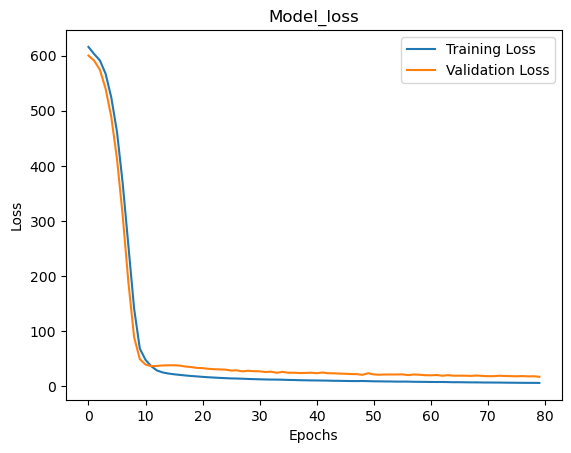

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Training Loss','Validation Loss'])
plt.show()